# Phase 7: Monte Carlo Simulation

## What this phase actually tests

Phase 6 reported one number per year: the profit that actually resulted
from the battery's forecast-driven decisions. But that's a single
realization of history. It doesn't tell you how much that outcome could
plausibly have varied if the forecast errors on those specific days had
happened to land differently. This phase asks, given the EXACT decisions
the battery already made (from Phase 6), how much does realized profit
vary across many statistically plausible alternate price outcomes?

## Key design decision: bootstrap real historical errors, not assumed noise

Rather than assuming forecast errors follow a clean bell curve (a common
simplification), we resample real historical residuals, preserving
whatever skew/heavy-tailedness the actual errors have. Recall Phase 5's
finding: price errors are NOT symmetric or well-behaved, concentrated
heavily around low-price hours.

**A further, important refinement: block bootstrap, not per-hour
bootstrap.** If you sampled a random error independently for each of the
24 hours in a day, you'd likely UNDERSTATE real risk -- errors are
probably correlated within a day (if the model misses an emerging cold
snap, EVERY hour that day is biased in the same direction, not
independently noisy). Instead, this resamples entire historical DAYS of
residuals as one block, preserving that realistic within-day correlation
structure.

## Where the residuals come from

The 2022 VALIDATION set - never the test years themselves. Characterizing
"the kind of errors this model tends to make" from validation data, then
applying that characterization uniformly to simulate uncertainty in 2023,
2024, and 2025, keeps this consistent with the leakage discipline we've used
everywhere else.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
np.random.seed(42)

N_SCENARIOS = 1000

train_df = pd.read_csv('../data/processed/price_forecast_train.csv', parse_dates=['datetime'])
val_df = train_df[train_df['datetime'] >= '2022-01-01'].copy()

## 1. Building the residual block library from validation data

Each "block" is one full day's 24 hourly residuals (actual - forecast),
kept together as a single unit - this is what gets resampled as a whole
during simulation, not individual hours.

In [2]:
val_df['date'] = val_df['datetime'].dt.date
val_df['residual'] = val_df['hoep'] - val_df['price_forecast']

residual_blocks = []
for date, day_df in val_df.groupby('date'):
    day_df = day_df.sort_values('datetime')
    if len(day_df) == 24:
        residual_blocks.append(day_df['residual'].values)

residual_blocks = np.array(residual_blocks)  # shape: (n_validation_days, 24)
print(f"Residual blocks: {residual_blocks.shape[0]} historical days, {residual_blocks.shape[1]} hours each")
print(f"Statistics - mean: {residual_blocks.mean():.2f}, std: {residual_blocks.std():.2f}, "
      f"min: {residual_blocks.min():.2f}, max: {residual_blocks.max():.2f}")

Residual blocks: 365 historical days, 24 hours each
Statistics - mean: 3.55, std: 29.67, min: -92.12, max: 631.98


## 2. The simulation itself

For each test day, and each of `N_SCENARIOS` random draws: pick a random
historical residual block, add it to that day's forecast prices to create
one plausible alternate "actual price" scenario, then evaluate the
already-decided battery schedule (loaded from Phase 6, not re-optimized)
against that simulated price. This is fully vectorized meaning no LP solving
happens here, just arithmetic, so 1000 scenarios across a full year runs
quickly.

In [3]:
def simulate_year(price_path, schedule_path, residual_blocks, n_scenarios=N_SCENARIOS):
    prices = pd.read_csv(price_path, parse_dates=['datetime'])
    schedule = pd.read_csv(schedule_path, parse_dates=['datetime'])
    merged = prices.merge(schedule, on='datetime')
    merged['date'] = merged['datetime'].dt.date

    n_blocks = len(residual_blocks)
    scenario_totals = np.zeros(n_scenarios)
    actual_total = 0.0

    for date, day_df in merged.groupby('date'):
        if len(day_df) != 24:
            continue
        day_df = day_df.sort_values('datetime')
        forecast_prices = day_df['price_forecast'].values
        actual_prices = day_df['hoep'].values
        charge = day_df['charge_mw'].values
        discharge = day_df['discharge_mw'].values

        # What actually happened (Phase 6's single realized outcome), for comparison
        actual_total += np.sum(discharge * actual_prices - charge * actual_prices)

        # Draw n_scenarios random historical residual blocks for this day
        block_idxs = np.random.randint(0, n_blocks, size=n_scenarios)
        sampled_residuals = residual_blocks[block_idxs]  # shape: (n_scenarios, 24)
        simulated_prices = forecast_prices[np.newaxis, :] + sampled_residuals  # (n_scenarios, 24)

        # Profit under each simulated scenario, given the ALREADY-DECIDED schedule
        day_profits = np.sum(simulated_prices * (discharge - charge)[np.newaxis, :], axis=1)
        scenario_totals += day_profits

    return scenario_totals, actual_total


sim_2023, actual_2023 = simulate_year(
    '../data/processed/price_forecast_test_2023.csv',
    '../data/processed/battery_schedule_test_2023.csv',
    residual_blocks,
)
sim_2024, actual_2024 = simulate_year(
    '../data/processed/price_forecast_test_2024.csv',
    '../data/processed/battery_schedule_test_2024.csv',
    residual_blocks,
)
sim_2025, actual_2025 = simulate_year(
    '../data/processed/price_forecast_test_2025.csv',
    '../data/processed/battery_schedule_test_2025.csv',
    residual_blocks,
)

## 3. Results: distributions, not single numbers

For each year: mean simulated outcome, a 90% interval (5th-95th
percentile), the probability of finishing with a loss, and where the
actual realized outcome falls within that distribution (a sanity check
on the simulation itself).

In [4]:
def summarize_simulation(sim_totals, actual_total, label):
    mean_sim = sim_totals.mean()
    p5, p95 = np.percentile(sim_totals, [5, 95])
    prob_loss = (sim_totals < 0).mean() * 100
    actual_percentile = (sim_totals < actual_total).mean() * 100

    print(f"--- {label} ---")
    print(f"  Simulated mean profit:        ${mean_sim:,.0f}")
    print(f"  90% interval:                 [${p5:,.0f}, ${p95:,.0f}]")
    print(f"  Probability of a loss:        {prob_loss:.1f}%")
    print(f"  Actual realized outcome:      ${actual_total:,.0f}  (percentile {actual_percentile:.0f} of simulated distribution)")
    print()

summarize_simulation(sim_2023, actual_2023, '2023')
summarize_simulation(sim_2024, actual_2024, '2024')
summarize_simulation(sim_2025, actual_2025, '2025 (partial)')

--- 2023 ---
  Simulated mean profit:        $673,885
  90% interval:                 [$583,662, $761,757]
  Probability of a loss:        0.0%
  Actual realized outcome:      $370,114  (percentile 0 of simulated distribution)

--- 2024 ---
  Simulated mean profit:        $724,673
  90% interval:                 [$641,160, $811,875]
  Probability of a loss:        0.0%
  Actual realized outcome:      $481,496  (percentile 0 of simulated distribution)

--- 2025 (partial) ---
  Simulated mean profit:        $368,862
  90% interval:                 [$318,807, $421,836]
  Probability of a loss:        0.0%
  Actual realized outcome:      $325,017  (percentile 8 of simulated distribution)



In [5]:
# Sanity check: Since the actual outcome falls in an extreme tail, the residual library built from 2022 may just
# simply understate how volatile/large real forecast erros were in the test years. To test this we can compute
# the real residuals in each test year and compare them against 2022 (the validation year) to confirm whether
# the simulation needs redefining or if there was an actual distribution shift
def residual_stats(price_path, label):
    df = pd.read_csv(price_path, parse_dates=['datetime'])
    residual = df['hoep'] - df['price_forecast']
    print(f"{label:>20}:  mean = {residual.mean():7.2f}   std = {residual.std():7.2f}   "
          f"5th pct = {residual.quantile(0.05):7.2f}   95th pct = {residual.quantile(0.95):7.2f}")

print("Residual volatility comparison (actual - forecast):")
residual_stats('../data/processed/price_forecast_train.csv', '2022 (validation)')
residual_stats('../data/processed/price_forecast_test_2023.csv', '2023 (test)')
residual_stats('../data/processed/price_forecast_test_2024.csv', '2024 (test)')
residual_stats('../data/processed/price_forecast_test_2025.csv', '2025 (test, partial)')

Residual volatility comparison (actual - forecast):
   2022 (validation):  mean =    0.17   std =   21.96   5th pct =  -21.29   95th pct =   25.15
         2023 (test):  mean =    0.68   std =   18.00   5th pct =  -17.43   95th pct =   16.64
         2024 (test):  mean =    2.56   std =   25.36   5th pct =  -16.41   95th pct =   23.66
2025 (test, partial):  mean =    7.82   std =   55.32   5th pct =  -28.00   95th pct =   63.41


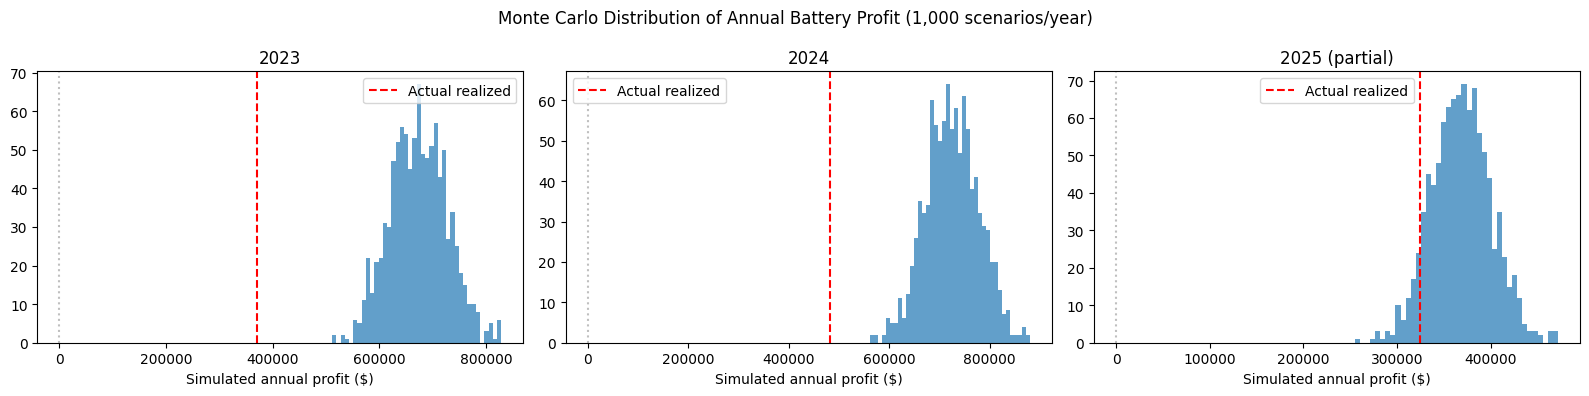

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, sim_totals, actual_total, year_label in zip(
    axes, [sim_2023, sim_2024, sim_2025], [actual_2023, actual_2024, actual_2025],
    ['2023', '2024', '2025 (partial)'],
):
    ax.hist(sim_totals, bins=40, alpha=0.7)
    ax.axvline(actual_total, color='red', linestyle='--', label='Actual realized')
    ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_title(year_label)
    ax.set_xlabel('Simulated annual profit ($)')
    ax.legend()

plt.suptitle('Monte Carlo Distribution of Annual Battery Profit (1,000 scenarios/year)')
plt.tight_layout()
plt.show()

## 4. Investigating historical price volatility

A tempting fix is to just use residuals from more years, but this would
backfire. 2002-2021 is in-sample for the price model (it was fit directly
on that data), so its residuals there are artificially small.
Bootstrapping from artificially-small in-sample residuals would make the
simulation more falsely confident, not less.

**What we can do instead: measure real historical price volatility directly,
independent of any model.** Compute how much actual HOEP deviated from a
smooth local seasonal baseline (a centered rolling mean) across all 20+
years of history -- a purely empirical measure of "how volatile has a real
day's price shape historically gotten," with no dependence on model fit
quality. This broadens tail-event coverage (including the 2002 market
volatility and COVID-era collapse from Phase 2) without the in-sample
bias trap.

In [7]:
full_history = pd.read_csv('../data/processed/price_forecast_train.csv', parse_dates=['datetime'])
full_history = full_history.sort_values('datetime').reset_index(drop=True)

# Smooth local baseline: centered 15-day rolling mean of actual price
full_history['baseline'] = full_history['hoep'].rolling(24 * 15, center=True, min_periods=24*7).mean()
full_history['shock'] = full_history['hoep'] - full_history['baseline']
full_history = full_history.dropna(subset=['shock'])
full_history['date'] = full_history['datetime'].dt.date

expanded_blocks = []
for date, day_df in full_history.groupby('date'):
    if len(day_df) == 24:
        expanded_blocks.append(day_df['shock'].values)

expanded_blocks = np.array(expanded_blocks)
print(f"Expanded price outlook: {expanded_blocks.shape[0]} historical days (vs. {residual_blocks.shape[0]} before)")
print(f"Statistics - mean: {expanded_blocks.mean():.2f}, std: {expanded_blocks.std():.2f}, "
      f"min: {expanded_blocks.min():.2f}, max: {expanded_blocks.max():.2f}")
print(f"(Compare to original 2022-only residual std: {residual_blocks.std():.2f})")

Expanded price outlook: 7535 historical days (vs. 365 before)
Statistics - mean: -0.01, std: 26.17, min: -164.82, max: 1644.80
(Compare to original 2022-only residual std: 29.67)


In [8]:
sim_2023_v2, _ = simulate_year(
    '../data/processed/price_forecast_test_2023.csv',
    '../data/processed/battery_schedule_test_2023.csv',
    expanded_blocks,
)
sim_2024_v2, _ = simulate_year(
    '../data/processed/price_forecast_test_2024.csv',
    '../data/processed/battery_schedule_test_2024.csv',
    expanded_blocks,
)
sim_2025_v2, _ = simulate_year(
    '../data/processed/price_forecast_test_2025.csv',
    '../data/processed/battery_schedule_test_2025.csv',
    expanded_blocks,
)

summarize_simulation(sim_2023_v2, actual_2023, '2023 (expanded library)')
summarize_simulation(sim_2024_v2, actual_2024, '2024 (expanded library)')
summarize_simulation(sim_2025_v2, actual_2025, '2025 (expanded library, partial)')

--- 2023 (expanded library) ---
  Simulated mean profit:        $1,280,365
  90% interval:                 [$1,208,059, $1,355,979]
  Probability of a loss:        0.0%
  Actual realized outcome:      $370,114  (percentile 0 of simulated distribution)

--- 2024 (expanded library) ---
  Simulated mean profit:        $1,334,754
  90% interval:                 [$1,260,751, $1,417,217]
  Probability of a loss:        0.0%
  Actual realized outcome:      $481,496  (percentile 0 of simulated distribution)

--- 2025 (expanded library, partial) ---
  Simulated mean profit:        $529,234
  90% interval:                 [$488,731, $573,246]
  Probability of a loss:        0.0%
  Actual realized outcome:      $325,017  (percentile 0 of simulated distribution)



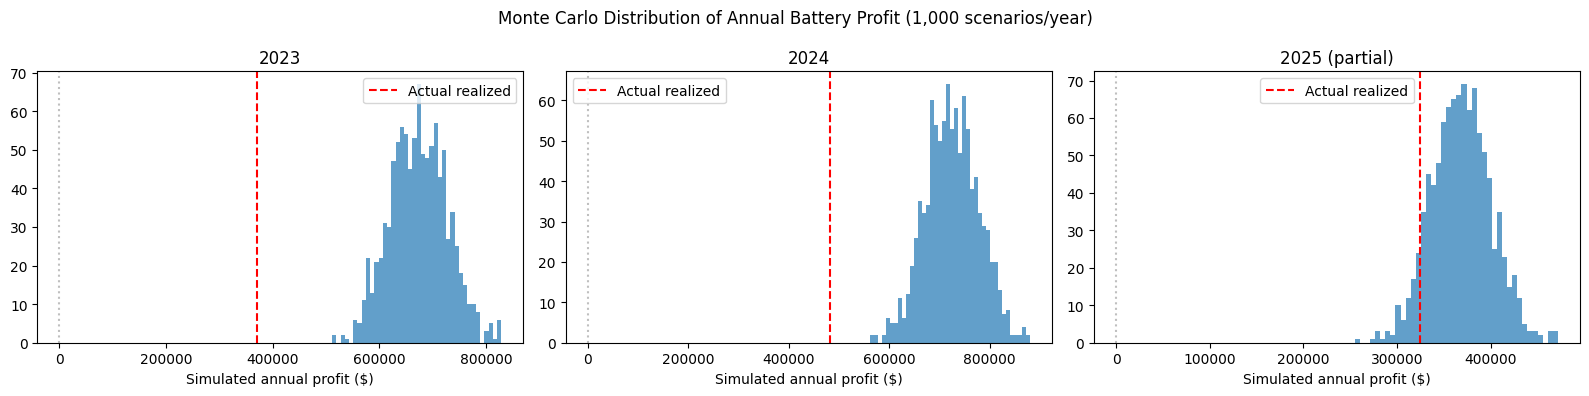

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, sim_totals, actual_total, year_label in zip(
    axes, [sim_2023, sim_2024, sim_2025], [actual_2023, actual_2024, actual_2025],
    ['2023', '2024', '2025 (partial)'],
):
    ax.hist(sim_totals, bins=40, alpha=0.7)
    ax.axvline(actual_total, color='red', linestyle='--', label='Actual realized')
    ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_title(year_label)
    ax.set_xlabel('Simulated annual profit ($)')
    ax.legend()

plt.suptitle('Monte Carlo Distribution of Annual Battery Profit (1,000 scenarios/year)')
plt.tight_layout()
plt.show()

## Summary

The expanded price outlook made the simulation even more overconfident, not less. It produced tighter, higher, unrealistically optimistic price ranges (0% chance of loss in every year), and the real outcome landed below the entire simulated range in all 3 years. This confirms the diagnosis from before that the reason is structural, not a data-size problem. I believe this structural underperformance is likely from the model getting timing wrong, as opposed to inaccuracies in the forecasts. A forecast can be decent on average while still getting the shape of a specific day wrong (e.g. predicting the evening peak will hit at hour 18 when it actually hits at hour 20, or undersestimating how extremely a particular spike will be - these errors will barely move the MAPE metric, but can completely flip a trading decision from profitable to a loss). Profitability completely depends on getting the relative timings of highs and lows right every day, and price's volatility, driven by supply-side influences my features can't capture, meant the forecast was wrong often enough on those high-stake days to turn a good average accuracy number into a big financial problem.